In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
from collections import defaultdict
import gzip
import math

<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13199/1813498717.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.text(75, 700, '$D_{agua-pura}=(10.23 \pm 6.52 ) \\mathrm{cm}$', color='red', fontsize=24)
/tmp/ipykernel_13199/1813498717.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.text(75, 600, '$D_{agua-2.5sal}=(9.89 \pm 6.3 ) \\mathrm{cm}$', color='green', fontsize=24)
/tmp/ipykernel_13199/1813498717.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.text(75, 500, '$D_{agua-5sal}=(9.71 \pm 6.16 ) \\mathrm{cm}$', color='purple', fontsize=24)
/tmp/ipykernel_13199/1813498717.py:49: SyntaxWarnin

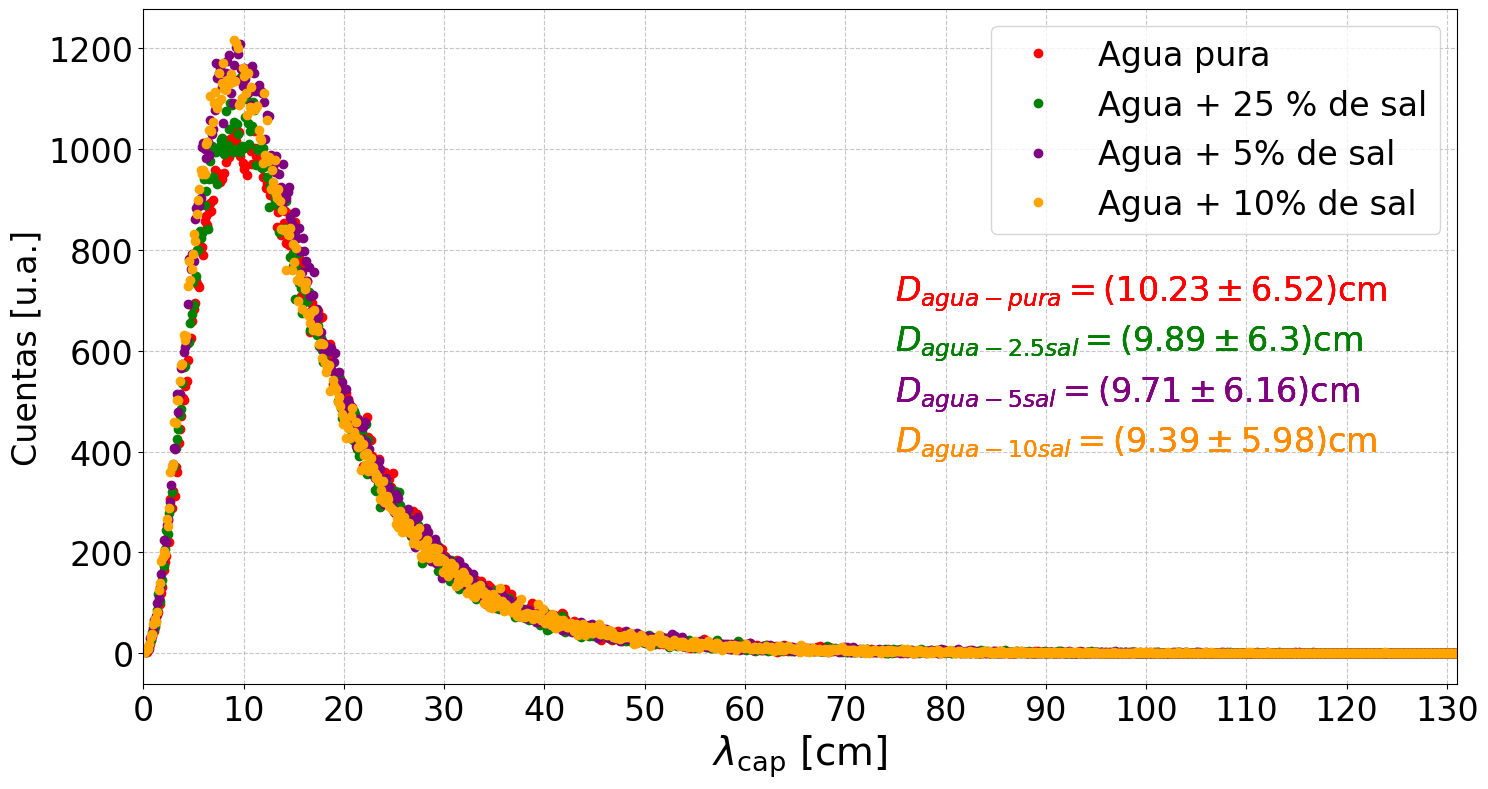

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Lista de archivos y etiquetas para cada conjunto de datos
archivos_datos = [
    ("Distancias_promedio_captura_Agua_pura_Flujo_Completo_1h.txt", "Agua pura", "red"),
    ("Distancias_promedio_captura_Agua_25NaCl_Flujo_Completo_1h.txt", "Agua + 25 % de sal", "green"),
    ("Distancias_promedio_captura_Agua_5NaCl_Flujo_Completo_1h.txt", "Agua + 5% de sal", "purple"),
    ("Distancias_promedio_captura_Agua_10NaCl_Flujo_Completo_1h.txt", "Agua + 10% de sal", "orange"),
]

# Inicializar figura
plt.figure(figsize=(15, 8))

# Configurar bins del histograma
bin_count = 1000

# Leer y graficar cada archivo
for archivo_entrada, etiqueta, color in archivos_datos:
    distancias = []

    # Leer el archivo
    with open(archivo_entrada, "r") as archivo:
        for num_linea, linea in enumerate(archivo, start=1):
            # Saltar las dos primeras líneas del encabezado
            if num_linea <= 2:
                continue
            
            # Dividir la línea y extraer datos
            columnas = linea.split()
            if len(columnas) >= 1:
                try:
                    distancia = float(columnas[0]) / 10  # Columna 2: Distancia Total
                    distancias.append(distancia)
                except ValueError:
                    print(f"Error procesando la línea {num_linea}: {linea.strip()}")

    # Calcular el histograma
    hist, bin_edges = np.histogram(distancias, bins=bin_count)

    # Calcular la parte central de cada bin
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Crear gráfico para este archivo
    plt.plot(bin_centers, hist, 'o', color=color, label=etiqueta)
    plt.text(75, 700, '$D_{agua-pura}=(10.23 \pm 6.52 ) \\mathrm{cm}$', color='red', fontsize=24)
    plt.text(75, 600, '$D_{agua-2.5sal}=(9.89 \pm 6.3 ) \\mathrm{cm}$', color='green', fontsize=24)
    plt.text(75, 500, '$D_{agua-5sal}=(9.71 \pm 6.16 ) \\mathrm{cm}$', color='purple', fontsize=24)
    plt.text(75, 400, '$D_{agua-10sal}=(9.39 \pm 5.98 ) \\mathrm{cm}$', color='darkorange', fontsize=24)
# Configurar etiquetas y título
plt.title("", fontsize=22)
#plt.xlabel("Distancia [cm]", fontsize=22)
plt.xlabel(r"$\lambda_{\text{cap}}$ [cm]", fontsize=28)
plt.xlim(0, 131)
plt.ylabel("Cuentas [u.a.]", fontsize=24)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.legend(fontsize=24)
plt.xticks(np.arange(0, 131, 10))
plt.tick_params(axis='x', which='both', labelsize=24)
plt.tick_params(axis='y', which='both', labelsize=24)

# Ajustar diseño y guardar la figura
plt.tight_layout()
plt.savefig('Histograma-Distancias-Captura-flujo-completo.pdf', format='pdf')
plt.savefig('Histograma-Distancias-Captura-flujo-completo.png', format='png')
plt.show()


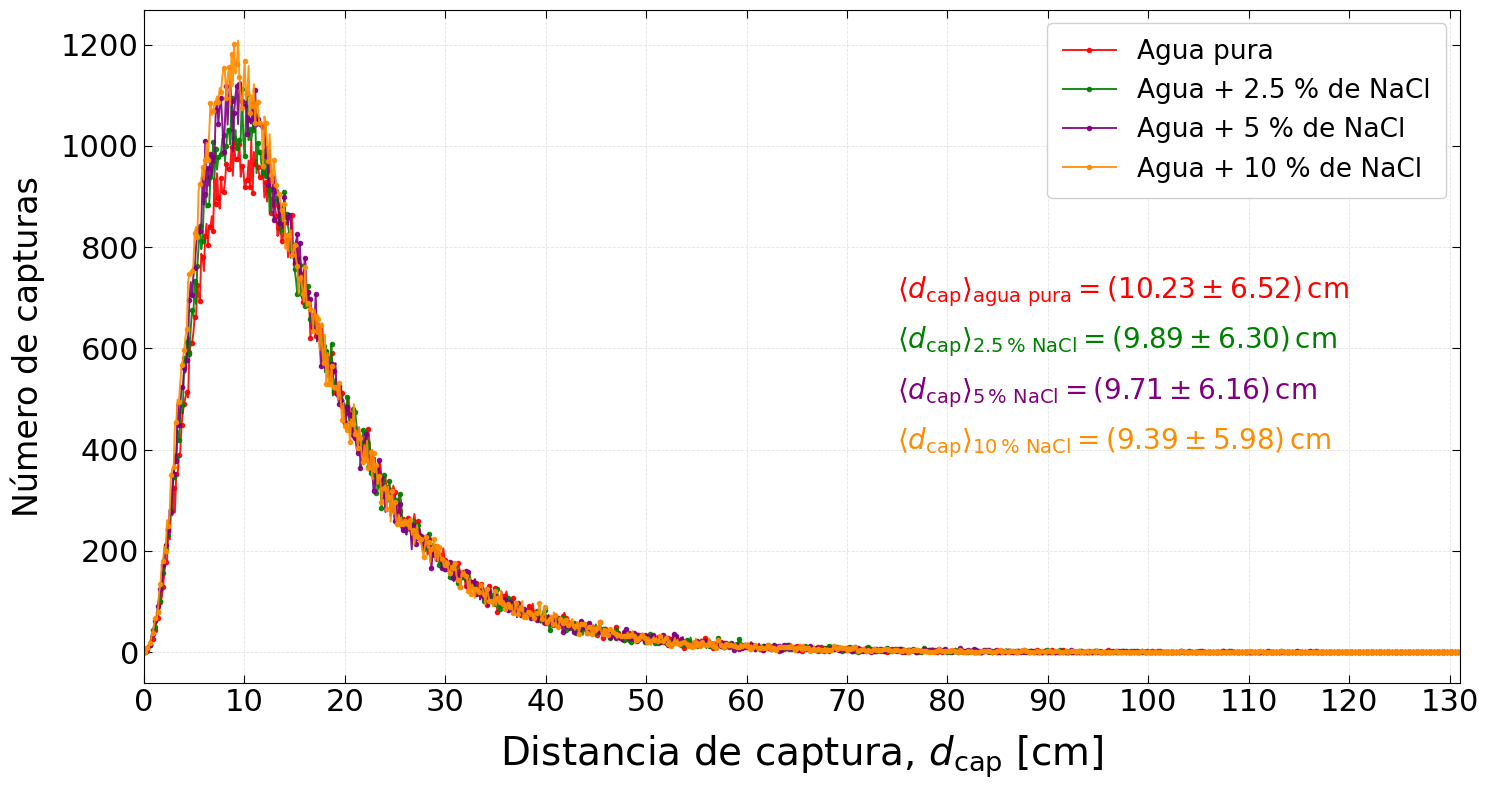

In [4]:
import matplotlib.pyplot as plt
import numpy as np


# ==========================================================
# ARCHIVOS, ETIQUETAS Y COLORES
# ==========================================================

archivos_datos = [
    (
        "Distancias_promedio_captura_Agua_pura_Flujo_Completo_1h.txt",
        "Agua pura",
        "red"
    ),
    (
        "Distancias_promedio_captura_Agua_25NaCl_Flujo_Completo_1h.txt",
        "Agua + 2.5 % de NaCl",
        "green"
    ),
    (
        "Distancias_promedio_captura_Agua_5NaCl_Flujo_Completo_1h.txt",
        "Agua + 5 % de NaCl",
        "purple"
    ),
    (
        "Distancias_promedio_captura_Agua_10NaCl_Flujo_Completo_1h.txt",
        "Agua + 10 % de NaCl",
        "darkorange"
    ),
]


# ==========================================================
# CONFIGURACIÓN DE LA FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(15, 8)
)

bin_count = 1000


# ==========================================================
# LECTURA Y GRAFICACIÓN
# ==========================================================

for archivo_entrada, etiqueta, color in archivos_datos:

    distancias = []

    with open(
        archivo_entrada,
        "r",
        encoding="utf-8"
    ) as archivo:

        for num_linea, linea in enumerate(
            archivo,
            start=1
        ):

            # Saltar las dos primeras líneas del encabezado
            if num_linea <= 2:
                continue

            columnas = linea.split()

            if len(columnas) >= 1:

                try:

                    # Conversión de mm a cm
                    distancia = float(columnas[0]) / 10.0

                    distancias.append(
                        distancia
                    )

                except ValueError:

                    print(
                        f"Error procesando la línea "
                        f"{num_linea}: "
                        f"{linea.strip()}"
                    )

    # Verificar que existan datos válidos
    if len(distancias) == 0:

        print(
            f"No se encontraron datos válidos en: "
            f"{archivo_entrada}"
        )

        continue

    # Histograma
    hist, bin_edges = np.histogram(
        distancias,
        bins=bin_count,
        range=(0, 131)
    )

    # Centros de los bins
    bin_centers = 0.5 * (
        bin_edges[:-1]
        + bin_edges[1:]
    )

    # Curva con marcadores pequeños
    ax.plot(
        bin_centers,
        hist,
        color=color,
        linewidth=1.4,
        marker="o",
        markersize=3.0,
        markevery=2,
        label=etiqueta,
        alpha=0.90
    )


# ==========================================================
# RESULTADOS ESTADÍSTICOS
# ==========================================================
#
# Se usan cadenas crudas r"..." para evitar el aviso:
# SyntaxWarning: invalid escape sequence '\p'
# ==========================================================

ax.text(
    75,
    700,
    r"$\langle d_{\mathrm{cap}}\rangle_{\mathrm{agua\ pura}}"
    r"=(10.23\pm6.52)\,\mathrm{cm}$",
    color="red",
    fontsize=20
)

ax.text(
    75,
    600,
    r"$\langle d_{\mathrm{cap}}\rangle_{2.5\,\%\ \mathrm{NaCl}}"
    r"=(9.89\pm6.30)\,\mathrm{cm}$",
    color="green",
    fontsize=20
)

ax.text(
    75,
    500,
    r"$\langle d_{\mathrm{cap}}\rangle_{5\,\%\ \mathrm{NaCl}}"
    r"=(9.71\pm6.16)\,\mathrm{cm}$",
    color="purple",
    fontsize=20
)

ax.text(
    75,
    400,
    r"$\langle d_{\mathrm{cap}}\rangle_{10\,\%\ \mathrm{NaCl}}"
    r"=(9.39\pm5.98)\,\mathrm{cm}$",
    color="darkorange",
    fontsize=20
)


# ==========================================================
# FORMATO DE LOS EJES
# ==========================================================

ax.set_xlabel(
    r"Distancia de captura, "
    r"$d_{\mathrm{cap}}$ [cm]",
    fontsize=28,
    labelpad=12
)

ax.set_ylabel(
    "Número de capturas",
    fontsize=24,
    labelpad=12
)

ax.set_xlim(
    0,
    131
)

ax.set_xticks(
    np.arange(
        0,
        131,
        10
    )
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=22,
    direction="in",
    length=6,
    top=True,
    right=True
)


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)


# ==========================================================
# LEYENDA
# ==========================================================

ax.legend(
    fontsize=19,
    loc="upper right",
    frameon=True,
    framealpha=0.92,
    borderpad=0.6,
    labelspacing=0.5,
    handlelength=2.0
)


# ==========================================================
# GUARDAR FIGURA
# ==========================================================

fig.tight_layout()

fig.savefig(
    "Histograma-Distancias-Captura-flujo-completo.pdf",
    format="pdf",
    bbox_inches="tight"
)

fig.savefig(
    "Histograma-Distancias-Captura-flujo-completo.png",
    format="png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

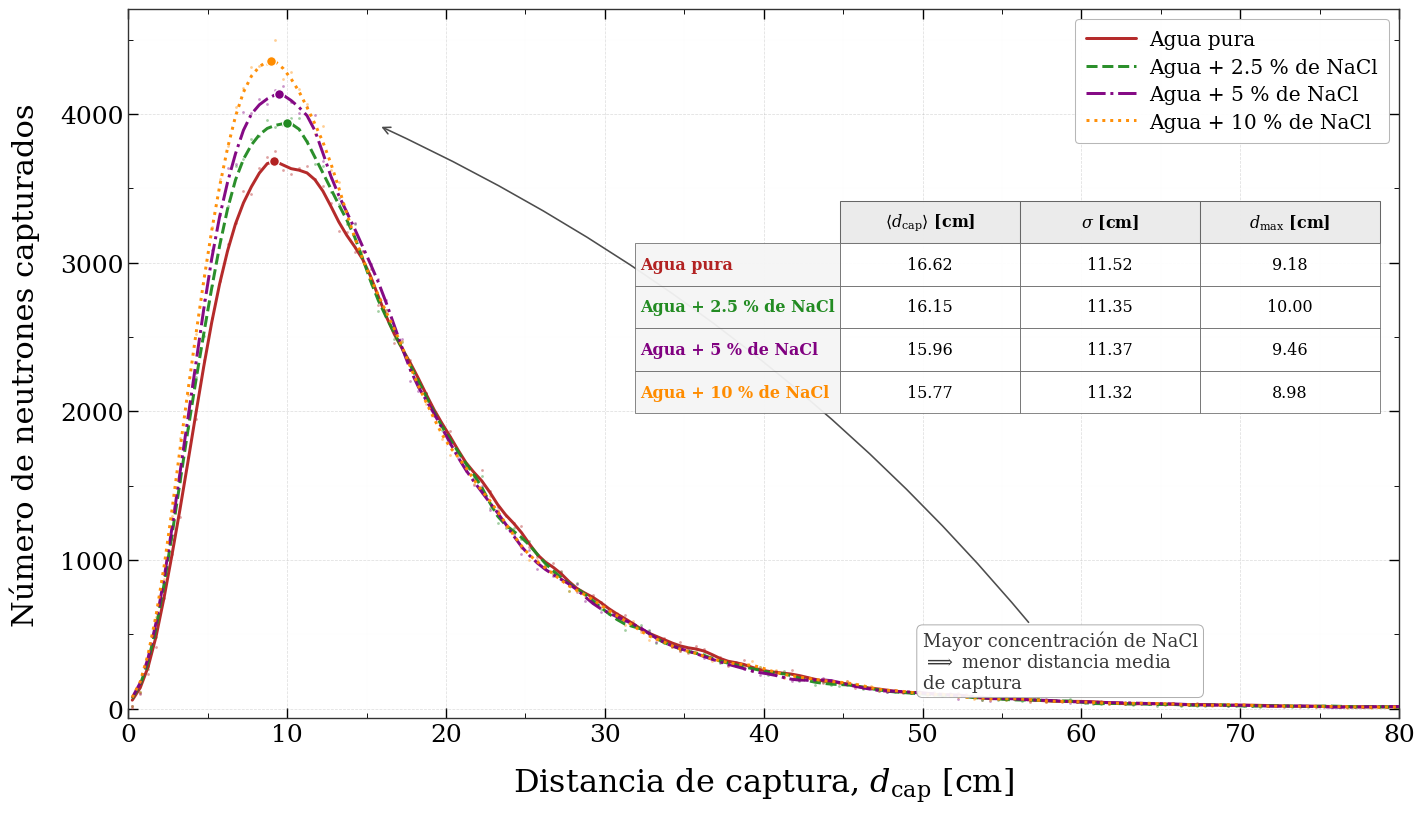


Figura generada correctamente.
--------------------------------
Directorio de salida: /home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Flujo-completo-Bga/Distancia-captura/Graficas-distancia-captura
PDF: Graficas-distancia-captura/Histograma-Distancias-Captura-flujo-completo-mejorado.pdf
PNG: Graficas-distancia-captura/Histograma-Distancias-Captura-flujo-completo-mejorado.png
Resultados: Graficas-distancia-captura/Histograma-Distancias-Captura-flujo-completo-mejorado-resultados.txt
Ancho de bin: 0.500000 cm

Resumen estadístico
-------------------

Agua pura
  Eventos       = 139,845
  Media         = 16.6213 cm
  Sigma         = 11.5196 cm
  Mediana       = 13.8067 cm
  Máximo        = 9.1850 cm
  Altura máxima = 3682.1080

Agua + 2.5 % de NaCl
  Eventos       = 143,806
  Media         = 16.1523 cm
  Sigma         = 11.3537 cm
  Mediana       = 13.3161 cm
  Máximo        = 10.0023 cm
  Altura máxima = 3940.1742

Agua + 5 % de NaCl
  Eventos       = 147,357
  Media         = 15.9629

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

DIRECTORIO_SALIDA = "Graficas-distancia-captura"

NOMBRE_BASE = (
    "Histograma-Distancias-Captura-"
    "flujo-completo-mejorado"
)

os.makedirs(
    DIRECTORIO_SALIDA,
    exist_ok=True
)

ARCHIVO_PDF = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + ".pdf"
)

ARCHIVO_PNG = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + ".png"
)

ARCHIVO_RESULTADOS = os.path.join(
    DIRECTORIO_SALIDA,
    NOMBRE_BASE + "-resultados.txt"
)


# ==========================================================
# ARCHIVOS, ETIQUETAS Y COLORES
# ==========================================================

archivos_datos = [
    (
        "Distancias_promedio_captura_Agua_pura_Flujo_Completo_1h.txt",
        "Agua pura",
        "firebrick",
        "-"
    ),
    (
        "Distancias_promedio_captura_Agua_25NaCl_Flujo_Completo_1h.txt",
        "Agua + 2.5 % de NaCl",
        "forestgreen",
        "--"
    ),
    (
        "Distancias_promedio_captura_Agua_5NaCl_Flujo_Completo_1h.txt",
        "Agua + 5 % de NaCl",
        "purple",
        "-."
    ),
    (
        "Distancias_promedio_captura_Agua_10NaCl_Flujo_Completo_1h.txt",
        "Agua + 10 % de NaCl",
        "darkorange",
        ":"
    ),
]


# ==========================================================
# PARÁMETROS DEL HISTOGRAMA
# ==========================================================

# Intervalo total utilizado para calcular el histograma
RANGO_MIN_CM = 0.0
RANGO_MAX_CM = 131.0

# Intervalo mostrado en la figura principal
X_MIN_FIGURA = 0.0
X_MAX_FIGURA = 80.0

# Número de bins comunes.
#
# 262 bins en 131 cm equivale aproximadamente a:
# 0.5 cm por bin.
NUMERO_BINS = 262

# Suavizado visual
APLICAR_SUAVIZADO = True
SIGMA_SUAVIZADO_BINS = 1.25

# Mostrar puntos correspondientes al histograma original
MOSTRAR_PUNTOS = True

# Mostrar la tabla estadística
MOSTRAR_TABLA = True

# Mostrar los máximos
MOSTRAR_MAXIMOS = True


# ==========================================================
# CONFIGURACIÓN TIPOGRÁFICA
# ==========================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",

    "font.size": 15,
    "axes.labelsize": 23,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,

    "axes.linewidth": 1.0,

    # Mantener fuentes editables en PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ==========================================================
# FUNCIÓN PARA LEER LAS DISTANCIAS
# ==========================================================

def leer_distancias(
    archivo_entrada,
    lineas_encabezado=2,
    factor_conversion=0.1
):
    """
    Lee la primera columna del archivo y convierte las
    distancias de mm a cm.

    factor_conversion = 0.1 equivale a dividir por 10.
    """

    distancias = []

    if not os.path.exists(archivo_entrada):
        raise FileNotFoundError(
            f"No se encontró el archivo:\n{archivo_entrada}"
        )

    with open(
        archivo_entrada,
        "r",
        encoding="utf-8"
    ) as archivo:

        for numero_linea, linea in enumerate(
            archivo,
            start=1
        ):

            if numero_linea <= lineas_encabezado:
                continue

            linea = linea.strip()

            if not linea:
                continue

            columnas = linea.split()

            if len(columnas) < 1:
                continue

            try:

                distancia_mm = float(
                    columnas[0]
                )

                distancia_cm = (
                    distancia_mm
                    * factor_conversion
                )

                if np.isfinite(distancia_cm):
                    distancias.append(
                        distancia_cm
                    )

            except ValueError:

                print(
                    f"Advertencia: no se pudo procesar "
                    f"la línea {numero_linea} de "
                    f"{archivo_entrada}:"
                )

                print(
                    linea
                )

    distancias = np.asarray(
        distancias,
        dtype=float
    )

    if distancias.size == 0:
        raise ValueError(
            f"No se encontraron distancias válidas en:\n"
            f"{archivo_entrada}"
        )

    return distancias


# ==========================================================
# SUAVIZADO GAUSSIANO SIN SCIPY
# ==========================================================

def suavizado_gaussiano(
    valores,
    sigma=1.0
):
    """
    Aplica un suavizado gaussiano unidimensional.

    El suavizado se utiliza solamente para mostrar la tendencia.
    Las medias y desviaciones estándar se calculan con los datos
    originales.
    """

    valores = np.asarray(
        valores,
        dtype=float
    )

    if sigma <= 0:
        return valores.copy()

    radio = max(
        1,
        int(np.ceil(4.0 * sigma))
    )

    posiciones = np.arange(
        -radio,
        radio + 1,
        dtype=float
    )

    kernel = np.exp(
        -0.5
        * (posiciones / sigma)**2
    )

    kernel /= np.sum(kernel)

    valores_ext = np.pad(
        valores,
        pad_width=radio,
        mode="edge"
    )

    suavizados = np.convolve(
        valores_ext,
        kernel,
        mode="same"
    )

    return suavizados[
        radio:-radio
    ]


# ==========================================================
# MÁXIMO REFINADO POR AJUSTE PARABÓLICO
# ==========================================================

def calcular_maximo_refinado(
    centros,
    valores
):
    """
    Refina la posición del máximo empleando el punto máximo y
    sus dos vecinos.
    """

    indice = int(
        np.argmax(valores)
    )

    x_max_bin = float(
        centros[indice]
    )

    y_max_bin = float(
        valores[indice]
    )

    if (
        indice == 0
        or indice == len(valores) - 1
    ):
        return (
            x_max_bin,
            y_max_bin
        )

    x_local = centros[
        indice - 1:indice + 2
    ]

    y_local = valores[
        indice - 1:indice + 2
    ]

    coeficientes = np.polyfit(
        x_local,
        y_local,
        2
    )

    a, b, c = coeficientes

    if np.isclose(a, 0.0):

        return (
            x_max_bin,
            y_max_bin
        )

    x_refinado = -b / (2.0 * a)

    x_refinado = float(
        np.clip(
            x_refinado,
            x_local[0],
            x_local[-1]
        )
    )

    y_refinado = float(
        a * x_refinado**2
        + b * x_refinado
        + c
    )

    return (
        x_refinado,
        y_refinado
    )


# ==========================================================
# BORDES COMUNES DEL HISTOGRAMA
# ==========================================================

bordes_comunes = np.linspace(
    RANGO_MIN_CM,
    RANGO_MAX_CM,
    NUMERO_BINS + 1
)

centros_comunes = 0.5 * (
    bordes_comunes[:-1]
    + bordes_comunes[1:]
)

ancho_bin_cm = (
    bordes_comunes[1]
    - bordes_comunes[0]
)


# ==========================================================
# CARGAR TODOS LOS DATOS
# ==========================================================

datos_configuraciones = []

for (
    archivo_entrada,
    etiqueta,
    color,
    estilo_linea
) in archivos_datos:

    distancias = leer_distancias(
        archivo_entrada
    )

    datos_configuraciones.append({
        "archivo": archivo_entrada,
        "etiqueta": etiqueta,
        "color": color,
        "estilo": estilo_linea,
        "distancias": distancias
    })


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(14.5, 8.4)
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

resultados = []


# ==========================================================
# CONSTRUIR Y GRAFICAR LAS DISTRIBUCIONES
# ==========================================================

for configuracion in datos_configuraciones:

    etiqueta = configuracion["etiqueta"]
    color = configuracion["color"]
    estilo = configuracion["estilo"]
    distancias = configuracion["distancias"]

    # ------------------------------------------------------
    # Histograma con bins comunes
    # ------------------------------------------------------

    cuentas, _ = np.histogram(
        distancias,
        bins=bordes_comunes
    )

    cuentas = cuentas.astype(float)

    # ------------------------------------------------------
    # Curva suavizada para visualización
    # ------------------------------------------------------

    if APLICAR_SUAVIZADO:

        curva_suavizada = suavizado_gaussiano(
            cuentas,
            sigma=SIGMA_SUAVIZADO_BINS
        )

    else:

        curva_suavizada = cuentas.copy()

    # ------------------------------------------------------
    # Estadísticos de los datos individuales
    # ------------------------------------------------------

    media = float(
        np.mean(distancias)
    )

    sigma = float(
        np.std(
            distancias,
            ddof=0
        )
    )

    mediana = float(
        np.median(distancias)
    )

    numero_eventos = int(
        len(distancias)
    )

    # ------------------------------------------------------
    # Máximo de la distribución
    # ------------------------------------------------------

    x_max, y_max = calcular_maximo_refinado(
        centros_comunes,
        curva_suavizada
    )

    resultados.append({
        "etiqueta": etiqueta,
        "color": color,
        "media": media,
        "sigma": sigma,
        "mediana": mediana,
        "numero_eventos": numero_eventos,
        "x_max": x_max,
        "y_max": y_max
    })

    # ------------------------------------------------------
    # Puntos correspondientes al histograma original
    # ------------------------------------------------------

    if MOSTRAR_PUNTOS:

        ax.plot(
            centros_comunes,
            cuentas,
            linestyle="none",
            marker="o",
            markersize=2.0,
            markerfacecolor=color,
            markeredgecolor=color,
            markeredgewidth=0.0,
            alpha=0.42,
            zorder=2
        )

    # ------------------------------------------------------
    # Curva principal suavizada
    # ------------------------------------------------------

    ax.plot(
        centros_comunes,
        curva_suavizada,
        color=color,
        linestyle=estilo,
        linewidth=2.15,
        label=etiqueta,
        alpha=0.96,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=4
    )

    # ------------------------------------------------------
    # Marcador del máximo
    # ------------------------------------------------------

    if MOSTRAR_MAXIMOS:

        ax.plot(
            x_max,
            y_max,
            marker="o",
            markersize=7.0,
            markerfacecolor=color,
            markeredgecolor="white",
            markeredgewidth=0.9,
            linestyle="none",
            zorder=7
        )


# ==========================================================
# FORMATO DE LOS EJES
# ==========================================================

ax.set_xlabel(
    r"Distancia de captura, "
    r"$d_{\mathrm{cap}}$ [cm]",
    fontsize=23,
    labelpad=14
)

ax.set_ylabel(
    "Número de neutrones capturados",
    fontsize=22,
    labelpad=14
)

ax.set_xlim(
    X_MIN_FIGURA,
    X_MAX_FIGURA
)

ax.set_xticks(
    np.arange(
        X_MIN_FIGURA,
        X_MAX_FIGURA + 1,
        10
    )
)

ax.xaxis.set_minor_locator(
    ticker.MultipleLocator(5)
)

ax.yaxis.set_minor_locator(
    ticker.AutoMinorLocator(2)
)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=7,
    width=1.0,
    labelsize=18,
    top=True,
    right=True
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3.5,
    width=0.65,
    top=True,
    right=True
)


# ==========================================================
# CUADRÍCULA
# ==========================================================

ax.grid(
    visible=True,
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.55,
    color="0.55",
    alpha=0.28
)

ax.grid(
    visible=True,
    which="minor",
    axis="both",
    linestyle=":",
    linewidth=0.30,
    color="0.65",
    alpha=0.10
)

ax.set_axisbelow(True)


# ==========================================================
# LEYENDA COMPACTA
# ==========================================================

leyenda = ax.legend(
    loc="upper right",
    fontsize=14.5,
    frameon=True,
    framealpha=0.95,
    facecolor="white",
    edgecolor="0.70",
    borderpad=0.55,
    labelspacing=0.42,
    handlelength=2.5,
    handletextpad=0.65,
    markerscale=0.85
)

leyenda.get_frame().set_linewidth(
    0.75
)


# ==========================================================
# TABLA ESTADÍSTICA
# ==========================================================

if MOSTRAR_TABLA:

    table_data = [
        [
            f"{resultado['media']:.2f}",
            f"{resultado['sigma']:.2f}",
            f"{resultado['x_max']:.2f}"
        ]
        for resultado in resultados
    ]

    row_labels = [
        resultado["etiqueta"]
        for resultado in resultados
    ]

    col_labels = [
        r"$\langle d_{\mathrm{cap}}\rangle$ [cm]",
        r"$\sigma$ [cm]",
        r"$d_{\max}$ [cm]"
    ]

    tabla = ax.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,

        # Posición: x, y, ancho y alto en coordenadas del eje
        bbox=[
            0.56,
            0.43,
            0.425,
            0.30
        ],

        cellLoc="center",
        colLoc="center",
        zorder=20
    )

    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11.5)

    cells = tabla.get_celld()

    # ------------------------------------------------------
    # Formato general
    # ------------------------------------------------------

    for (
        fila,
        columna
    ), celda in cells.items():

        celda.set_edgecolor(
            "0.40"
        )

        celda.set_linewidth(
            0.55
        )

        celda.set_facecolor(
            (
                1.0,
                1.0,
                1.0,
                0.93
            )
        )

        celda.PAD = 0.025

    # ------------------------------------------------------
    # Encabezados
    # ------------------------------------------------------

    for columna in range(
        len(col_labels)
    ):

        celda = cells[
            (0, columna)
        ]

        celda.set_facecolor(
            (
                0.92,
                0.92,
                0.92,
                0.97
            )
        )

        celda.set_text_props(
            weight="bold",
            color="black",
            fontsize=11.5
        )

        celda.set_linewidth(
            0.75
        )

    # ------------------------------------------------------
    # Etiquetas de fila
    # ------------------------------------------------------

    for indice, resultado in enumerate(
        resultados,
        start=1
    ):

        celda = cells[
            (indice, -1)
        ]

        celda.set_text_props(
            color=resultado["color"],
            weight="bold",
            fontsize=11.5
        )

        celda.set_facecolor(
            (
                0.96,
                0.96,
                0.96,
                0.95
            )
        )


# ==========================================================
# ANOTACIÓN DE LA TENDENCIA FÍSICA
# ==========================================================

ax.annotate(
    (
        "Mayor concentración de NaCl\n"
        r"$\Longrightarrow$ menor distancia media"
        "\nde captura"
    ),

    xy=(
        resultados[-1]["media"],
        0.90 * resultados[-1]["y_max"]
    ),

    xytext=(
        50,
        320
    ),

    fontsize=13.0,
    ha="left",
    va="center",
    color="0.22",

    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.15,
        color="0.30",
        connectionstyle="arc3,rad=0.12"
    ),

    bbox=dict(
        boxstyle="round,pad=0.32",
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.7,
        alpha=0.92
    ),

    zorder=16
)


# ==========================================================
# BORDES DE LA FIGURA
# ==========================================================

for spine in ax.spines.values():

    spine.set_linewidth(
        1.0
    )

    spine.set_color(
        "0.20"
    )


# ==========================================================
# AJUSTAR LÍMITE VERTICAL
# ==========================================================

maximo_global = max(
    resultado["y_max"]
    for resultado in resultados
)

ax.set_ylim(
    bottom=-0.015 * maximo_global,
    top=1.08 * maximo_global
)


# ==========================================================
# GUARDAR RESULTADOS NUMÉRICOS
# ==========================================================

with open(
    ARCHIVO_RESULTADOS,
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        "# Distribución de las distancias de captura\n"
    )

    archivo.write(
        "# Distancias convertidas de mm a cm\n"
    )

    archivo.write(
        f"# Número de bins: {NUMERO_BINS}\n"
    )

    archivo.write(
        f"# Ancho de bin: {ancho_bin_cm:.8f} cm\n"
    )

    archivo.write(
        "#\n"
    )

    archivo.write(
        "# Medio\t"
        "N_eventos\t"
        "Media_cm\t"
        "Sigma_cm\t"
        "Mediana_cm\t"
        "Posicion_maximo_cm\t"
        "Altura_maximo\n"
    )

    for resultado in resultados:

        archivo.write(
            f"{resultado['etiqueta']}\t"
            f"{resultado['numero_eventos']}\t"
            f"{resultado['media']:.10f}\t"
            f"{resultado['sigma']:.10f}\t"
            f"{resultado['mediana']:.10f}\t"
            f"{resultado['x_max']:.10f}\t"
            f"{resultado['y_max']:.10f}\n"
        )


# ==========================================================
# GUARDAR FIGURA
# ==========================================================

fig.tight_layout()

fig.savefig(
    ARCHIVO_PDF,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

fig.savefig(
    ARCHIVO_PNG,
    format="png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white"
)

plt.show()
plt.close(fig)


# ==========================================================
# INFORMACIÓN EN TERMINAL
# ==========================================================

print("\nFigura generada correctamente.")
print("--------------------------------")

print(
    f"Directorio de salida: "
    f"{os.path.abspath(DIRECTORIO_SALIDA)}"
)

print(
    f"PDF: {ARCHIVO_PDF}"
)

print(
    f"PNG: {ARCHIVO_PNG}"
)

print(
    f"Resultados: {ARCHIVO_RESULTADOS}"
)

print(
    f"Ancho de bin: {ancho_bin_cm:.6f} cm"
)

print("\nResumen estadístico")
print("-------------------")

for resultado in resultados:

    print(
        f"\n{resultado['etiqueta']}"
    )

    print(
        f"  Eventos       = "
        f"{resultado['numero_eventos']:,}"
    )

    print(
        f"  Media         = "
        f"{resultado['media']:.4f} cm"
    )

    print(
        f"  Sigma         = "
        f"{resultado['sigma']:.4f} cm"
    )

    print(
        f"  Mediana       = "
        f"{resultado['mediana']:.4f} cm"
    )

    print(
        f"  Máximo        = "
        f"{resultado['x_max']:.4f} cm"
    )

    print(
        f"  Altura máxima = "
        f"{resultado['y_max']:.4f}"
    )

Ingrese el límite inferior del intervalo de ajuste:  5
Ingrese el límite superior del intervalo de ajuste:  15
Ingrese una estimación inicial de la amplitud:  1000


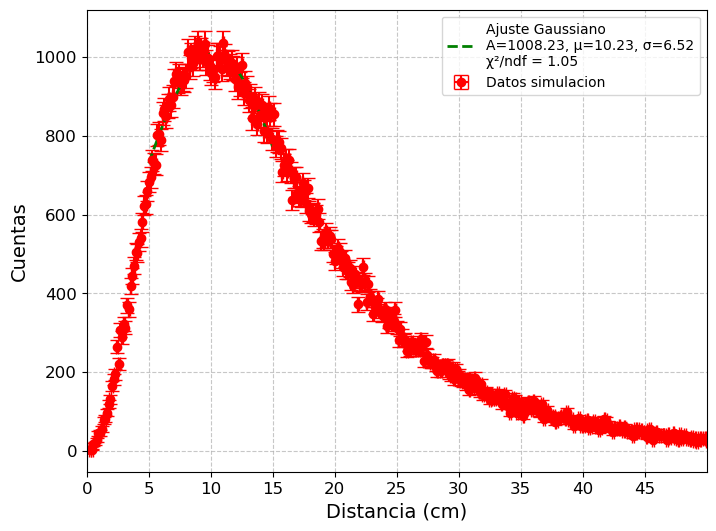

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Función gaussiana
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Leer los datos desde un archivo (reemplazar 'datos.txt' con el nombre real)
archivo = "Distancias_promedio_captura_Agua_pura_Flujo_Completo_1h.txt"
with open(archivo, "r") as f:
    datos = [float(linea.strip())/10 for linea in f]

# Definir el número de bins
num_bins = 1000  # Puedes ajustar este valor

# Calcular el histograma
hist, bin_edges = np.histogram(datos, bins=num_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Centros de los bins
bin_widths = np.diff(bin_edges)  # Ancho de cada bin

# Calcular barras de error
error_y = np.where(hist > 0, np.sqrt(hist), 0)  # Evita divisiones por cero
error_x = bin_widths / 2  # La mitad del ancho del bin

# Graficar el histograma como polígono con barras de error
plt.figure(figsize=(8, 6))
#plt.plot(bin_centers, hist, marker='o', linestyle='-', color='b', label="Histograma (polígono)")
plt.errorbar(bin_centers, hist, yerr=error_y, xerr=error_x, fmt='o', color='r', capsize=5, label="Datos simulacion")

    # Etiquetas específicas en las barras del histograma
 

# ====== Ajuste Gaussiano ======
# Pedir valores desde consola
x_min = float(input("Ingrese el límite inferior del intervalo de ajuste: "))
x_max = float(input("Ingrese el límite superior del intervalo de ajuste: "))
A_init = float(input("Ingrese una estimación inicial de la amplitud: "))

# Filtrar los datos en el intervalo de ajuste
mask = (bin_centers >= x_min) & (bin_centers <= x_max)
x_data = bin_centers[mask]
y_data = hist[mask]
y_err = error_y[mask]  # Errores

# Valores iniciales para el ajuste: [A, mu, sigma]
p0 = [A_init, np.mean(x_data), np.std(x_data)]

# Ajuste por Chi-cuadrado
popt, pcov = curve_fit(gaussiana, x_data, y_data, p0=p0, sigma=y_err, absolute_sigma=True)
A_fit, mu_fit, sigma_fit = popt
chi2 = np.sum(((y_data - gaussiana(x_data, *popt)) / y_err) ** 2)
ndf = len(y_data) - len(popt)
chi2_ndf = chi2 / ndf

# Graficar la curva ajustada
x_fit = np.linspace(x_min, x_max, 1000)
y_fit = gaussiana(x_fit, *popt)
plt.plot(x_fit, y_fit, 'g--', linewidth=2, label=f"Ajuste Gaussiano\nA={A_fit:.2f}, μ={mu_fit:.2f}, σ={sigma_fit:.2f}\nχ²/ndf = {chi2_ndf:.2f}")

# Etiquetas y título
plt.xlabel("Distancia (cm)", fontsize=14)
plt.xlim(0, 50)
plt.ylabel("Cuentas", fontsize=14)
plt.xticks(np.arange(0, 50, 5))
plt.title("", fontsize=16)
plt.tick_params(axis='x', which='both', labelsize=12)
plt.tick_params(axis='y', which='both', labelsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig('Ajuste-Distancia-Agua-pura.pdf', format='pdf')
plt.savefig('Ajuste-Distancia-Agua-pura.jpg', format='jpg')
plt.show()


Ingrese el límite inferior del intervalo de ajuste:  5
Ingrese el límite superior del intervalo de ajuste:  15
Ingrese una estimación inicial de la amplitud:  1020


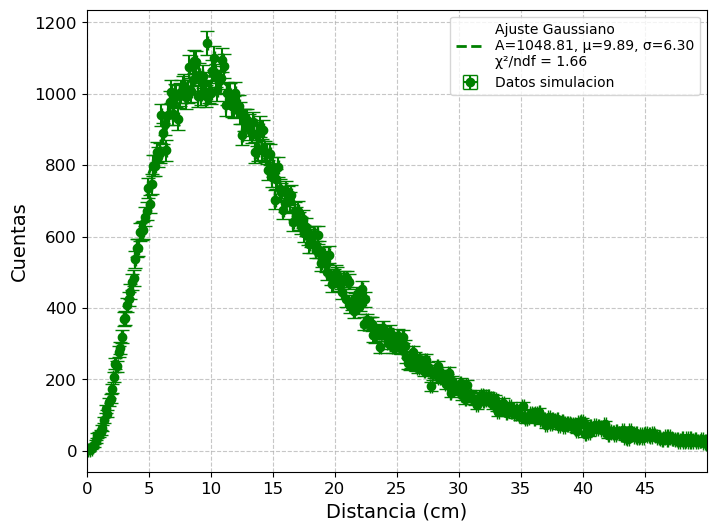

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Función gaussiana
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Leer los datos desde un archivo (reemplazar 'datos.txt' con el nombre real)
archivo = "Distancias_promedio_captura_Agua_25NaCl_Flujo_Completo_1h.txt"
with open(archivo, "r") as f:
    datos = [float(linea.strip())/10 for linea in f]

# Definir el número de bins
num_bins = 1000  # Puedes ajustar este valor

# Calcular el histograma
hist, bin_edges = np.histogram(datos, bins=num_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Centros de los bins
bin_widths = np.diff(bin_edges)  # Ancho de cada bin

# Calcular barras de error
error_y = np.where(hist > 0, np.sqrt(hist), 0)  # Evita divisiones por cero
error_x = bin_widths / 2  # La mitad del ancho del bin

# Graficar el histograma como polígono con barras de error
plt.figure(figsize=(8, 6))
#plt.plot(bin_centers, hist, marker='o', linestyle='-', color='b', label="Histograma (polígono)")
plt.errorbar(bin_centers, hist, yerr=error_y, xerr=error_x, fmt='o', color='green', capsize=5, label="Datos simulacion")

    # Etiquetas específicas en las barras del histograma
 

# ====== Ajuste Gaussiano ======
# Pedir valores desde consola
x_min = float(input("Ingrese el límite inferior del intervalo de ajuste: "))
x_max = float(input("Ingrese el límite superior del intervalo de ajuste: "))
A_init = float(input("Ingrese una estimación inicial de la amplitud: "))

# Filtrar los datos en el intervalo de ajuste
mask = (bin_centers >= x_min) & (bin_centers <= x_max)
x_data = bin_centers[mask]
y_data = hist[mask]
y_err = error_y[mask]  # Errores

# Valores iniciales para el ajuste: [A, mu, sigma]
p0 = [A_init, np.mean(x_data), np.std(x_data)]

# Ajuste por Chi-cuadrado
popt, pcov = curve_fit(gaussiana, x_data, y_data, p0=p0, sigma=y_err, absolute_sigma=True)
A_fit, mu_fit, sigma_fit = popt
chi2 = np.sum(((y_data - gaussiana(x_data, *popt)) / y_err) ** 2)
ndf = len(y_data) - len(popt)
chi2_ndf = chi2 / ndf

# Graficar la curva ajustada
x_fit = np.linspace(x_min, x_max, 1000)
y_fit = gaussiana(x_fit, *popt)
plt.plot(x_fit, y_fit, 'g--', linewidth=2, label=f"Ajuste Gaussiano\nA={A_fit:.2f}, μ={mu_fit:.2f}, σ={sigma_fit:.2f}\nχ²/ndf = {chi2_ndf:.2f}")

# Etiquetas y título
plt.xlabel("Distancia (cm)", fontsize=14)
plt.xlim(0, 50)
plt.ylabel("Cuentas", fontsize=14)
plt.xticks(np.arange(0, 50, 5))
plt.title("", fontsize=16)
plt.tick_params(axis='x', which='both', labelsize=12)
plt.tick_params(axis='y', which='both', labelsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig('Ajuste-Distancia-Agua-25NaCl.pdf', format='pdf')
plt.savefig('Ajuste-Distancia-Agua-25NaCl.jpg', format='jpg')
plt.show()


Ingrese el límite inferior del intervalo de ajuste:  5
Ingrese el límite superior del intervalo de ajuste:  15
Ingrese una estimación inicial de la amplitud:  1180


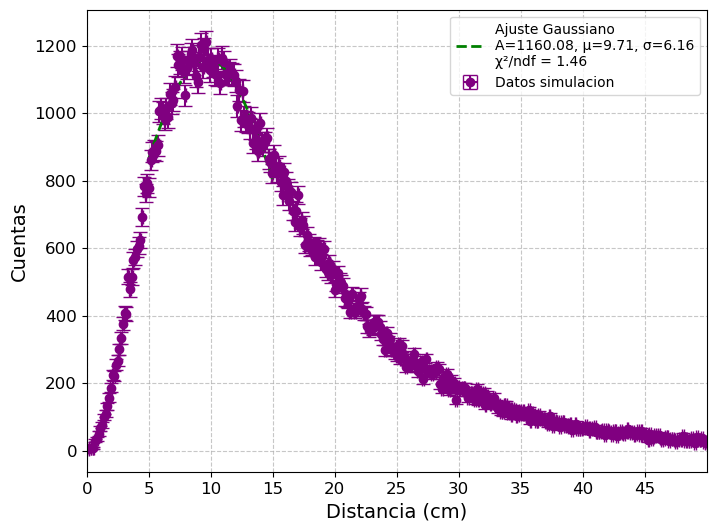

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Función gaussiana
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Leer los datos desde un archivo (reemplazar 'datos.txt' con el nombre real)
archivo = "Distancias_promedio_captura_Agua_5NaCl_Flujo_Completo_1h.txt"
with open(archivo, "r") as f:
    datos = [float(linea.strip())/10 for linea in f]

# Definir el número de bins
num_bins = 1000  # Puedes ajustar este valor

# Calcular el histograma
hist, bin_edges = np.histogram(datos, bins=num_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Centros de los bins
bin_widths = np.diff(bin_edges)  # Ancho de cada bin

# Calcular barras de error
error_y = np.where(hist > 0, np.sqrt(hist), 0)  # Evita divisiones por cero
error_x = bin_widths / 2  # La mitad del ancho del bin

# Graficar el histograma como polígono con barras de error
plt.figure(figsize=(8, 6))
#plt.plot(bin_centers, hist, marker='o', linestyle='-', color='b', label="Histograma (polígono)")
plt.errorbar(bin_centers, hist, yerr=error_y, xerr=error_x, fmt='o', color='purple', capsize=5, label="Datos simulacion")

    # Etiquetas específicas en las barras del histograma
 

# ====== Ajuste Gaussiano ======
# Pedir valores desde consola
x_min = float(input("Ingrese el límite inferior del intervalo de ajuste: "))
x_max = float(input("Ingrese el límite superior del intervalo de ajuste: "))
A_init = float(input("Ingrese una estimación inicial de la amplitud: "))

# Filtrar los datos en el intervalo de ajuste
mask = (bin_centers >= x_min) & (bin_centers <= x_max)
x_data = bin_centers[mask]
y_data = hist[mask]
y_err = error_y[mask]  # Errores

# Valores iniciales para el ajuste: [A, mu, sigma]
p0 = [A_init, np.mean(x_data), np.std(x_data)]

# Ajuste por Chi-cuadrado
popt, pcov = curve_fit(gaussiana, x_data, y_data, p0=p0, sigma=y_err, absolute_sigma=True)
A_fit, mu_fit, sigma_fit = popt
chi2 = np.sum(((y_data - gaussiana(x_data, *popt)) / y_err) ** 2)
ndf = len(y_data) - len(popt)
chi2_ndf = chi2 / ndf

# Graficar la curva ajustada
x_fit = np.linspace(x_min, x_max, 1000)
y_fit = gaussiana(x_fit, *popt)
plt.plot(x_fit, y_fit, 'g--', linewidth=2, label=f"Ajuste Gaussiano\nA={A_fit:.2f}, μ={mu_fit:.2f}, σ={sigma_fit:.2f}\nχ²/ndf = {chi2_ndf:.2f}")

# Etiquetas y título
plt.xlabel("Distancia (cm)", fontsize=14)
plt.xlim(0, 50)
plt.ylabel("Cuentas", fontsize=14)
plt.xticks(np.arange(0, 50, 5))
plt.title("", fontsize=16)
plt.tick_params(axis='x', which='both', labelsize=12)
plt.tick_params(axis='y', which='both', labelsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig('Ajuste-Distancia-Agua-5NaCl.pdf', format='pdf')
plt.savefig('Ajuste-Distancia-Agua-5NaCl.jpg', format='jpg')
plt.show()


Ingrese el límite inferior del intervalo de ajuste:  5
Ingrese el límite superior del intervalo de ajuste:  15
Ingrese una estimación inicial de la amplitud:  1200


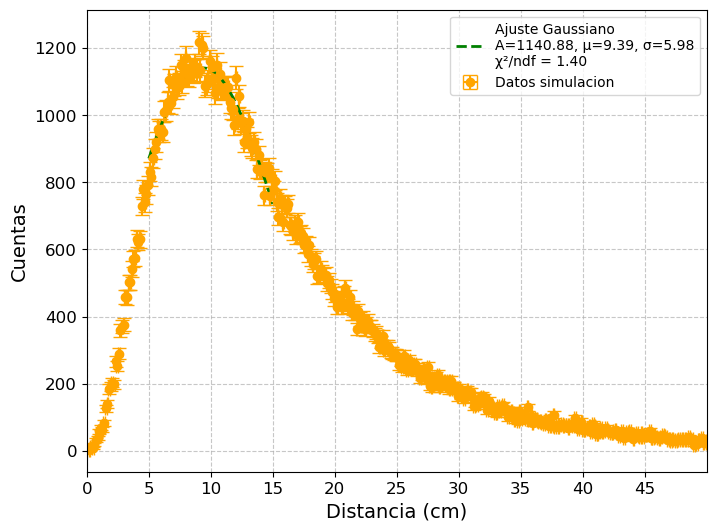

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Función gaussiana
def gaussiana(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Leer los datos desde un archivo (reemplazar 'datos.txt' con el nombre real)
archivo = "Distancias_promedio_captura_Agua_10NaCl_Flujo_Completo_1h.txt"
with open(archivo, "r") as f:
    datos = [float(linea.strip())/10 for linea in f]

# Definir el número de bins
num_bins = 1000  # Puedes ajustar este valor

# Calcular el histograma
hist, bin_edges = np.histogram(datos, bins=num_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Centros de los bins
bin_widths = np.diff(bin_edges)  # Ancho de cada bin

# Calcular barras de error
error_y = np.where(hist > 0, np.sqrt(hist), 0)  # Evita divisiones por cero
error_x = bin_widths / 2  # La mitad del ancho del bin

# Graficar el histograma como polígono con barras de error
plt.figure(figsize=(8, 6))
#plt.plot(bin_centers, hist, marker='o', linestyle='-', color='b', label="Histograma (polígono)")
plt.errorbar(bin_centers, hist, yerr=error_y, xerr=error_x, fmt='o', color='orange', capsize=5, label="Datos simulacion")

    # Etiquetas específicas en las barras del histograma
 

# ====== Ajuste Gaussiano ======
# Pedir valores desde consola
x_min = float(input("Ingrese el límite inferior del intervalo de ajuste: "))
x_max = float(input("Ingrese el límite superior del intervalo de ajuste: "))
A_init = float(input("Ingrese una estimación inicial de la amplitud: "))

# Filtrar los datos en el intervalo de ajuste
mask = (bin_centers >= x_min) & (bin_centers <= x_max)
x_data = bin_centers[mask]
y_data = hist[mask]
y_err = error_y[mask]  # Errores

# Valores iniciales para el ajuste: [A, mu, sigma]
p0 = [A_init, np.mean(x_data), np.std(x_data)]

# Ajuste por Chi-cuadrado
popt, pcov = curve_fit(gaussiana, x_data, y_data, p0=p0, sigma=y_err, absolute_sigma=True)
A_fit, mu_fit, sigma_fit = popt
chi2 = np.sum(((y_data - gaussiana(x_data, *popt)) / y_err) ** 2)
ndf = len(y_data) - len(popt)
chi2_ndf = chi2 / ndf

# Graficar la curva ajustada
x_fit = np.linspace(x_min, x_max, 1000)
y_fit = gaussiana(x_fit, *popt)
plt.plot(x_fit, y_fit, 'g--', linewidth=2, label=f"Ajuste Gaussiano\nA={A_fit:.2f}, μ={mu_fit:.2f}, σ={sigma_fit:.2f}\nχ²/ndf = {chi2_ndf:.2f}")

# Etiquetas y título
plt.xlabel("Distancia (cm)", fontsize=14)
plt.xlim(0, 50)
plt.ylabel("Cuentas", fontsize=14)
plt.xticks(np.arange(0, 50, 5))
plt.title("", fontsize=16)
plt.tick_params(axis='x', which='both', labelsize=12)
plt.tick_params(axis='y', which='both', labelsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig('Ajuste-Distancia-Agua-10NaCl.pdf', format='pdf')
plt.savefig('Ajuste-Distancia-Agua-10NaCl.jpg', format='jpg')
plt.show()


In [13]:
from collections import Counter

# Nombre del archivo
archivo = "secondary-particles-neutron-capturado.txt"

# Inicializar contador para las palabras
contador_palabras = Counter()

# Abrir y leer el archivo línea por línea
with open(archivo, "r") as file:
    for linea in file:
        columnas = linea.split()  # Dividir la línea en columnas
        if columnas:  # Verificar que la línea no esté vacía
            contador_palabras[columnas[0]] += 1  # Contar la palabra de la primera columna

# Imprimir los resultados
print("Conteo de palabras en la columna 1:")
for palabra, conteo in contador_palabras.items():
    print(f"{palabra}: {conteo}")


Conteo de palabras en la columna 1:
deuteron: 74035
gamma: 74167
N15: 13
O17: 28
Si29: 2
B11: 1
